# 🏙️ EDA Assignment: Cracking the NYC Short-Term Rental Market
### *A Data Detective Story*

---

**Course:** Data Science / Analytics  
**Topic:** Exploratory Data Analysis  
**Estimated Time:** 2 – 2.5 hours  
**Total Marks:** 100

---

## 📖 Background & Case Study

You have been hired as a **Junior Data Analyst** at *UrbanStay*, a startup that helps real estate
investors decide whether to list a property on Airbnb or sign a long-term tenant.
Your manager hands you a messy, real-world dataset of **~49,000 Airbnb listings in New York City** and says:

> *We have three investors coming in Friday. One wants to buy in Manhattan, one is eyeing Brooklyn,
> and one has no idea. Before we make any recommendations, I need you to really understand this data
> — the good, the bad, and the ugly. EDA only, no ML yet.*

Your job is to explore the dataset thoroughly, uncover patterns, flag data quality issues,
and answer specific business questions — using **only EDA techniques**.

---

## 📦 The Dataset

**Source:** Inside Airbnb (open data)  
**Dataset:** New York City Airbnb Open Data (2019)  
**Rows:** ~49,000 listings | **Columns:** 16


In [1]:
# ── SETUP: Run this cell first ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# ── LOAD DATA ────────────────────────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\hp\Desktop\AB_NYC_2019.csv")
print(f"Data loaded successfully!")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")


Data loaded successfully!
Shape: 48,895 rows x 16 columns


---

## 🗂️ Column Reference

| Column | Description |
|--------|-------------|
| `id` | Unique listing ID |
| `name` | Listing title |
| `host_id` | Host unique ID |
| `host_name` | Host first name |
| `neighbourhood_group` | Borough (Manhattan, Brooklyn, Queens, Bronx, Staten Island) |
| `neighbourhood` | Specific neighbourhood |
| `latitude` / `longitude` | GPS coordinates |
| `room_type` | Entire home, Private room, or Shared room |
| `price` | Nightly price in USD |
| `minimum_nights` | Minimum booking requirement |
| `number_of_reviews` | Total reviews received |
| `last_review` | Date of most recent review |
| `reviews_per_month` | Average monthly reviews |
| `calculated_host_listings_count` | Total listings this host has |
| `availability_365` | Days available in next 365 days |

---

## ⚠️ Ground Rules

1. Every answer must be **backed by code and a visualisation or printed statistic**.
2. Write your **interpretation** in the Markdown cell below each task.
3. No machine learning. No predictive models. EDA only.
4. Plots must have **titles, axis labels, and legends** where appropriate.
5. All cells must run **top-to-bottom without errors**.

---


# 🔎 PART 1 — First Contact with the Data
### (15 Marks)

Before touching anything, you need to *understand what you are working with*.


### Task 1.1 — Initial Inspection (5 marks)

Display the first few rows, data types, and summary statistics.

Then answer:
- How many numerical vs categorical columns are there?
- Does anything **immediately** look suspicious or unexpected?

> 💡 *Hint: There are multiple pandas methods designed exactly for this.
> Think about what a doctor does before diagnosing — they observe first.*


In [2]:
# Your code here
print(df.head())



     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [4]:
print(df.describe())

                 id       host_id      latitude     longitude         price  \
count  4.889500e+04  4.889500e+04  48895.000000  48895.000000  48895.000000   
mean   1.901714e+07  6.762001e+07     40.728949    -73.952170    152.720687   
std    1.098311e+07  7.861097e+07      0.054530      0.046157    240.154170   
min    2.539000e+03  2.438000e+03     40.499790    -74.244420      0.000000   
25%    9.471945e+06  7.822033e+06     40.690100    -73.983070     69.000000   
50%    1.967728e+07  3.079382e+07     40.723070    -73.955680    106.000000   
75%    2.915218e+07  1.074344e+08     40.763115    -73.936275    175.000000   
max    3.648724e+07  2.743213e+08     40.913060    -73.712990  10000.000000   

       minimum_nights  number_of_reviews  reviews_per_month  \
count    48895.000000       48895.000000       38843.000000   
mean         7.029962          23.274466           1.373221   
std         20.510550          44.550582           1.680442   
min          1.000000           0.00

**✍️ Your Interpretation:**  
*(Write here)*
- How many numerical vs categorical columns are there?
**ANS#1!**There are 10 coloumns are numericals and 06 are categoricals.

- Does anything **immediately** look suspicious or unexpected?
**ANS#2!** yes,there is some commonly mistake that i see,the price coloumn have most different values such as max have 10000 and min have 0.The average price is 152 that is so less as compare to max price.reviews_per_month also have some null values.


### Task 1.2 — Missing Value Audit (5 marks)

Identify **all missing values** across every column.
Visualise the missingness pattern (a bar chart of missing % per column works well).

Then answer:
- Which columns have missing data and what % is missing?
- For each missing column, *why* might the data be absent? Is it random or does it make business sense?
- What would you recommend doing about each? (Do not act yet — just recommend.)

> 💡 *Hint: Missing data is almost never random.
> Think carefully about when `reviews_per_month` would logically be empty.*


In [5]:
# Your code here
print((df.isnull().sum() / len(df)) * 100)


id                                 0.000000
name                               0.032723
host_id                            0.000000
host_name                          0.042949
neighbourhood_group                0.000000
neighbourhood                      0.000000
latitude                           0.000000
longitude                          0.000000
room_type                          0.000000
price                              0.000000
minimum_nights                     0.000000
number_of_reviews                  0.000000
last_review                       20.558339
reviews_per_month                 20.558339
calculated_host_listings_count     0.000000
availability_365                   0.000000
dtype: float64


In [6]:
df[df['reviews_per_month'].isnull()][['number_of_reviews','reviews_per_month']].head()

,number_of_reviews,reviews_per_month
2,0,NaN
19,0,NaN
26,0,NaN
36,0,NaN
38,0,NaN


**✍️ Your Interpretation:**  
*(Write here)*
 Which columns have missing data and what % is missing?
 There are four coloumn have missing data the first 2 coloumn(name,host_name) have very less missing data which can be negligible and the 2nd two coloumn(last_review,reviews_per_month ) have 20.56% missing data.

 For each missing column, *why* might the data be absent? Is it random or does it make business sense?
 The missing values are exist in reviews_per_month coloumn,if the listing of reviews is zero the reviews_per_month is not calculated based on listing of reviews.so this is logical sense not a random.

 What would you recommend doing about each? (Do not act yet — just recommend.)
 

### Task 1.3 — Duplicate Check (5 marks)

Check for duplicate rows. Also verify whether `id` (listing ID) is truly unique.
Report any anomalies you find.

> 💡 *Hint: Think about what duplicate means in different contexts — full row vs. key column.*


In [7]:
# Your code here
print(df.duplicated().sum())
df['id'].nunique()
len(df['id'].unique())

0


48895

**✍️ Your Interpretation:**  
*(Write here)*
0 duplicate and 48895 unique id


---

# 💰 PART 2 — The Price Puzzle
### (25 Marks)

Price is the most important variable for your investors.
Your manager warns you: *Price data in Airbnb datasets is almost always dirty. Tread carefully.*


### Task 2.1 — Price Distribution (8 marks)

Plot the distribution of `price`. Then plot it again after applying an appropriate transformation.

Answer:
- What is the shape of the original distribution? Use correct statistical terms.

- Are there listings with a price of **$0**? How many? What should you do with them?
Number of listings with $0 price: 11.In real life the price connot be zero,there will be taken as a mistake or represent missing values.we should be impute such type of missing values.

- After handling $0 listings, what does the distribution look like? What is a typical price?
After handling 0$ listings many bins(log price) are grow towards count.

> 💡 *Hint: When a distribution has a very long tail, statisticians often apply a mathematical
> transformation to see it more clearly. What transformation works well for right-skewed, positive data?*


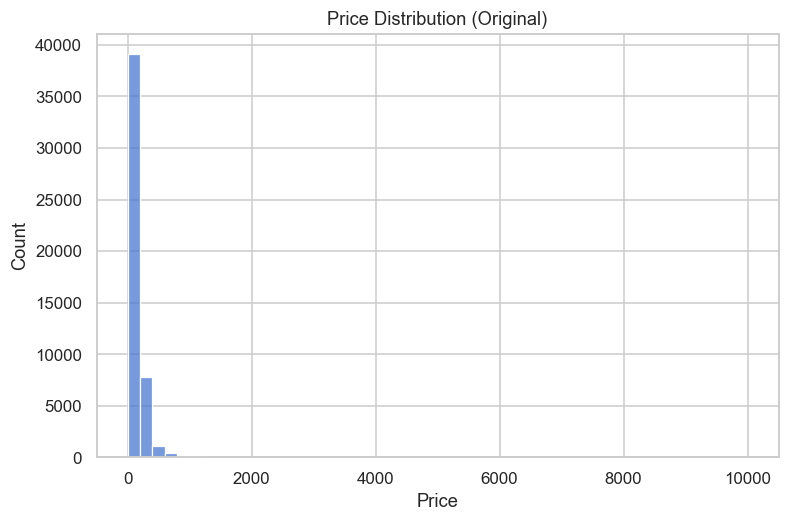

In [8]:
# Your code here
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=50)
plt.title("Price Distribution (Original)")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

In [9]:
# Count listings with price = 0
zero_price_count = (df['price'] == 0).sum()
print("Number of listings with $0 price:", zero_price_count)

Number of listings with $0 price: 11


In [10]:
df_price = df[df['price'] > 0]

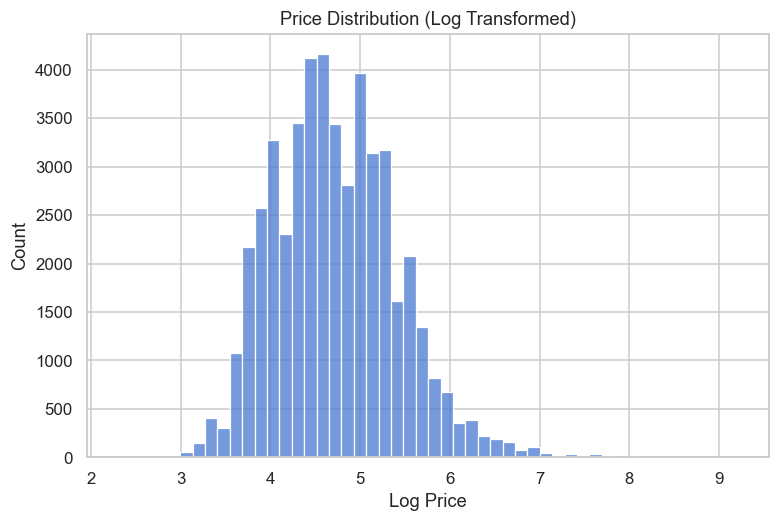

In [11]:

plt.figure(figsize=(8,5))
sns.histplot(np.log(df_price['price']), bins=50)
plt.title("Price Distribution (Log Transformed)")
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*


### Task 2.2 — Price by Borough (9 marks)

Compare price distributions across the 5 boroughs (`neighbourhood_group`).
Use **at least two different plot types**.

Answer:
- Which borough is most expensive on **median** price? Which on **mean**? Are they the same borough? Why might they differ?
Both median and mean price on Manhattan is expensive from the plot.
- Which borough has the most price variability? What does that mean for an investor?
Manhattan has most price variability.
- Where are outliers most extreme?
Manhattan has the most extreme high-price outliers, shown in the top whiskers of the box plot.

> 💡 *Hint: Mean and median tell different stories.
> A box plot and a violin plot each reveal something the other does not.*


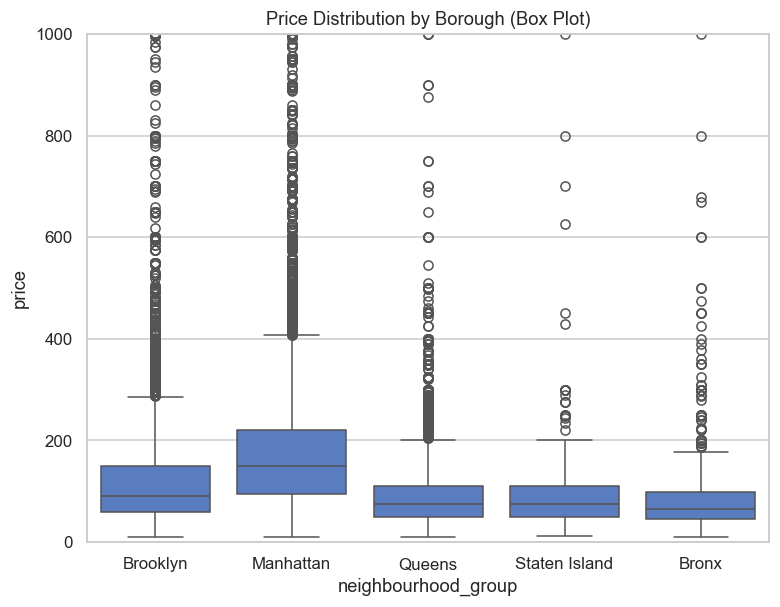

In [12]:
# Your code here
plt.figure(figsize=(8,6))
sns.boxplot(x='neighbourhood_group', y='price', data=df_price)
plt.title("Price Distribution by Borough (Box Plot)")
plt.ylim(0, 1000)  # optional: zoom in to avoid extreme outliers dominating the plot
plt.show()

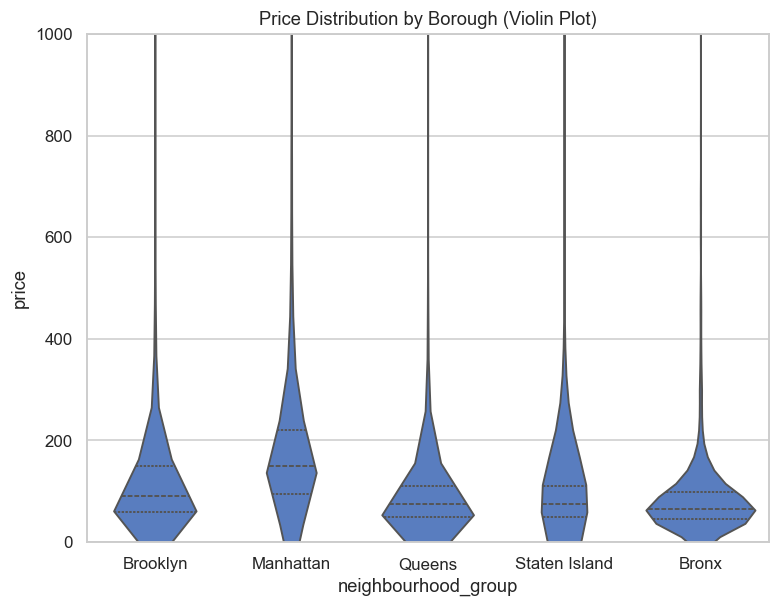

In [13]:
plt.figure(figsize=(8,6))
sns.violinplot(x='neighbourhood_group', y='price', data=df_price, inner="quartile")
plt.title("Price Distribution by Borough (Violin Plot)")
plt.ylim(0, 1000)
plt.show()

In [14]:
median_prices = df_price.groupby('neighbourhood_group')['price'].median()
mean_prices = df_price.groupby('neighbourhood_group')['price'].mean()

print("Median prices by borough:\n", median_prices)
print("\nMean prices by borough:\n", mean_prices)

Median prices by borough:
 neighbourhood_group
Bronx             65.0
Brooklyn          90.0
Manhattan        150.0
Queens            75.0
Staten Island     75.0
Name: price, dtype: float64

Mean prices by borough:
 neighbourhood_group
Bronx             87.577064
Brooklyn         124.438915
Manhattan        196.884903
Queens            99.517649
Staten Island    114.812332
Name: price, dtype: float64


**✍️ Your Interpretation:**  
*(Write here)*


### Task 2.3 — Price by Room Type (8 marks)

Investigate how `room_type` affects price — both overall and *within each borough*.
A heatmap or grouped bar chart of **median prices** could work well.

Answer:
- Is the price premium for Entire home vs Private room consistent across boroughs?
The Entire home/apt price is premium as compare to private room.

- Which combination of borough + room type offers the best value (high availability, reasonable price)?

> 💡 *Hint: Pivot tables are your friend here.
> Think about what rows, columns, and values should represent.*


In [15]:
# Your code here
median_price_room = df_price.groupby('room_type')['price'].median()
print("Median price by room type:\n", median_price_room)

Median price by room type:
 room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0
Name: price, dtype: float64


In [16]:
median_price_borough_room = df_price.groupby(['neighbourhood_group', 'room_type'])['price'].median().unstack()
print(median_price_borough_room)

room_type            Entire home/apt  Private room  Shared room
neighbourhood_group                                            
Bronx                          100.0          54.0         40.0
Brooklyn                       145.0          65.0         36.0
Manhattan                      191.0          90.0         69.0
Queens                         120.0          60.0         37.0
Staten Island                  100.0          50.0         30.0


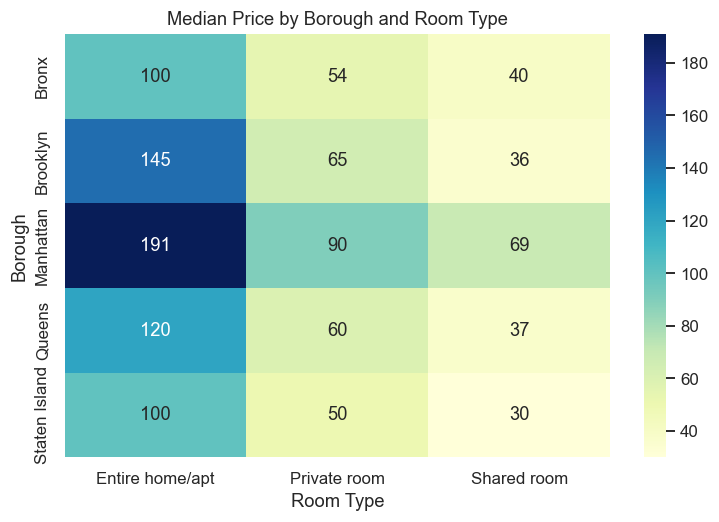

In [17]:
plt.figure(figsize=(8,5))
sns.heatmap(median_price_borough_room, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Median Price by Borough and Room Type")
plt.ylabel("Borough")
plt.xlabel("Room Type")
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*


---

# 🏠 PART 3 — Host Behaviour & Market Structure
### (20 Marks)

Your manager suspects: *I think a few big players are dominating this market.
If that is true, it changes our advice to investors completely.*


### Task 3.1 — Host Concentration Analysis (10 marks)

Analyse the `calculated_host_listings_count` column.

- What % of hosts have **only 1 listing**? What % have **more than 10**?
Percentage of hosts with 1 listing: 86.24% and Percentage of hosts with >10 listings: 0.25%.

- Plot the distribution of host listing counts (be careful with scale).

- Calculate: the top **1% of hosts** control what % of all listings?
86.24% 
- Is the NYC Airbnb market dominated by individual hosts or by commercial operators?
In the NYC Airbnb market dominated by individual hosts because the commercial operartor number is less then individual host but its have most listing.
> 💡 *Hint: Think about how economists measure inequality.
> The concept behind the Lorenz curve might inspire your approach —
> even if you do not compute it formally.*


In [18]:
# Your code here
# Total number of hosts
total_hosts = df['host_id'].nunique()

# Hosts with only 1 listing
hosts_1_listing = df[df['calculated_host_listings_count'] == 1]['host_id'].nunique()
pct_1_listing = (hosts_1_listing / total_hosts) * 100

# Hosts with more than 10 listings
hosts_gt10 = df[df['calculated_host_listings_count'] > 10]['host_id'].nunique()
pct_gt10 = (hosts_gt10 / total_hosts) * 100

print(f"Percentage of hosts with 1 listing: {pct_1_listing:.2f}%")
print(f"Percentage of hosts with >10 listings: {pct_gt10:.2f}%")

Percentage of hosts with 1 listing: 86.24%
Percentage of hosts with >10 listings: 0.25%


In [19]:
host_listings = df.groupby('host_id')['calculated_host_listings_count'].first().sort_values(ascending=False)

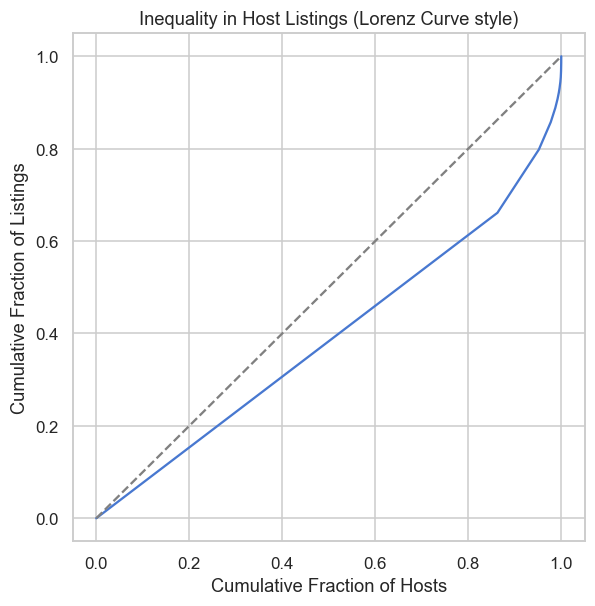

In [20]:
# Fraction of listings controlled cumulatively
host_sorted = host_listings.sort_values()
cumulative_listings = host_sorted.cumsum() / host_sorted.sum()

plt.figure(figsize=(6,6))
plt.plot(np.linspace(0,1,len(cumulative_listings)), cumulative_listings)
plt.plot([0,1],[0,1], '--', color='grey')  # line of equality
plt.xlabel("Cumulative Fraction of Hosts")
plt.ylabel("Cumulative Fraction of Listings")
plt.title("Inequality in Host Listings (Lorenz Curve style)")
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*


### Task 3.2 — Activity vs Ghost Listings (10 marks)

The `last_review` column tells you when a listing was last reviewed.
Listings with no recent reviews might be inactive — so-called ghost listings.

- Convert `last_review` to datetime. Calculate days since last review relative to **2019-07-08** (snapshot date).
- What % of listings have had **no review in the past year**? Past 6 months?
- Is there a relationship between `availability_365` and review activity? Plot and interpret.
- Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.

> 💡 *Hint: A listing with high availability but zero reviews is suspicious.
> What business scenario could explain that combination?*


In [21]:
# Your code here
# cONVERT LAST REVIEW DATE TO DATETIME
df['last_review'] = pd.to_datetime(df['last_review'], errors='coerce')
print(df['last_review'].head())

0   2018-10-19
1   2019-05-21
2          NaT
3   2019-07-05
4   2018-11-19
Name: last_review, dtype: datetime64[ns]


In [27]:
#Calculate days since last review (snapshot date = 2019-07-08)
snapshot_date = pd.to_datetime('2019-07-08')
df['days_since_last_review'] = (snapshot_date - df['last_review']).dt.days

In [29]:
#% of listings have had no review in the past year AND 6 MONTHS
no_review_1yr = (df['days_since_last_review'] > 365).mean() * 100
no_review_6mo = (df['days_since_last_review'] > 182).mean() * 100
print(f"Percentage of listings with no review in past year: {no_review_1yr:.2f}%")
print(f"Percentage of listings with no review in past 6 months: {no_review_6mo:.2f}%")

Percentage of listings with no review in past year: 19.82%
Percentage of listings with no review in past 6 months: 29.96%


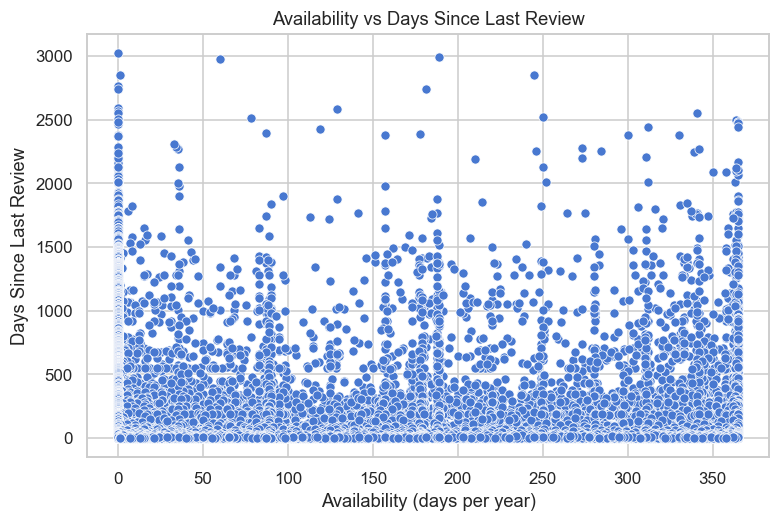

In [33]:
# Is there a relationship between `availability_365` and review activity? Plot and interpret.
# Create a scatter plot of availability_365 vs days_since_last_review
plt.figure(figsize=(8,5))
sns.scatterplot(x='availability_365', y='days_since_last_review', data=df)
plt.title("Availability vs Days Since Last Review")
plt.xlabel("Availability (days per year)")
plt.ylabel("Days Since Last Review")
plt.show()

In [ ]:
 #Do ghost listings (inactive 1+ year) charge different prices than active listings? Compare distributions.
ghost_listings = df[df['days_since_last_review'] > 365]


Text(0.5, 1.0, 'Price Distribution: Ghost vs Active Listings')

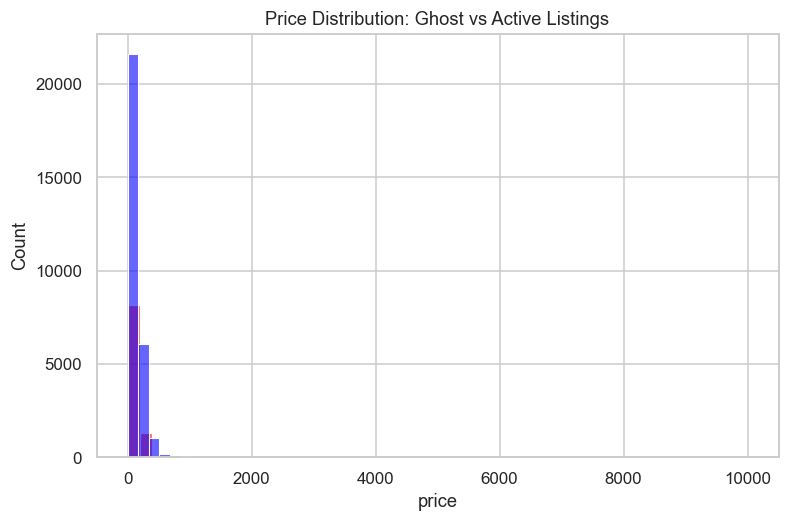

In [37]:
#Compare price distributions of ghost listings vs active listings
plt.figure(figsize=(8,5))
sns.histplot(ghost_listings['price'], bins=50, color='red', label='Ghost Listings', alpha=0.6)
sns.histplot(df[df['days_since_last_review'] <= 365]['price'], bins=50, color='blue', label='Active Listings', alpha=0.6)
plt.title("Price Distribution: Ghost vs Active Listings")       

**✍️ Your Interpretation:**  
*(Write here)*


---

# 🗺️ PART 4 — Geographic Deep Dive
### (20 Marks)

Location is everything in real estate.
Your investors will ask: *Where exactly should we buy?*


### Task 4.1 — Neighbourhood Density & Pricing (10 marks)

- Find the **Top 10 neighbourhoods** by listing count. Visualise.
- For those top 10, plot their **median price**. Is listing density correlated with price?
- Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
  (use a log scale for colour if needed). What geographic pattern do you observe?

there is no pricing in any region,i see the large number of 0s,mostly the range of price is lies in (0,4000).

> 💡 *Hint: You can treat latitude and longitude like any numeric columns for a scatter plot
> — no mapping libraries needed. The shape of NYC will emerge from the data itself.*


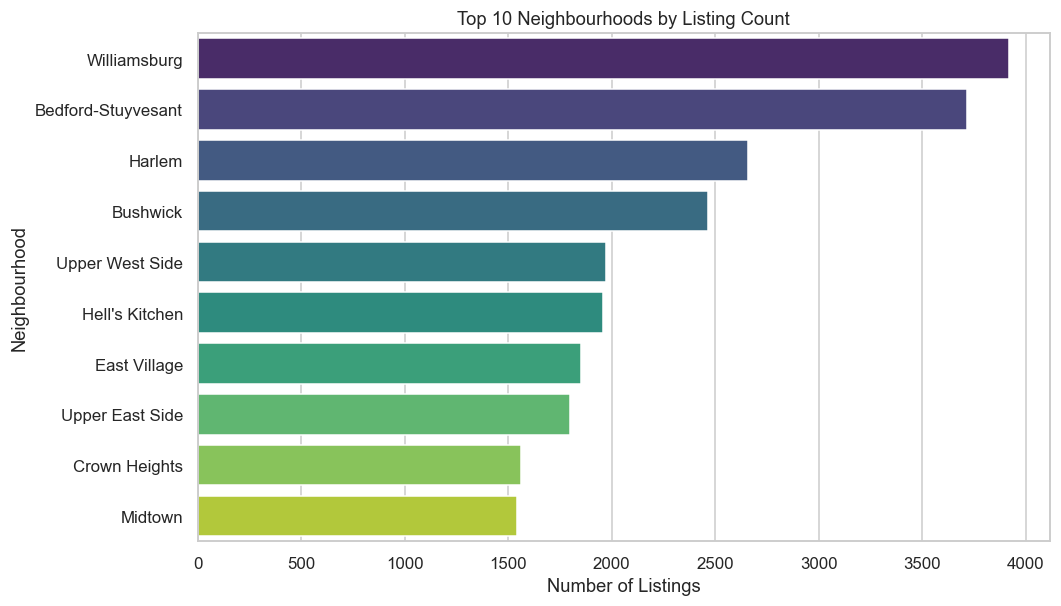

In [38]:
# Your code here
#Find the **Top 10 neighbourhoods** by listing count. Visualise.
top_neighbourhoods = df['neighbourhood'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=top_neighbourhoods.values, y=top_neighbourhoods.index, palette='viridis')
plt.title("Top 10 Neighbourhoods by Listing Count")
plt.xlabel("Number of Listings")
plt.ylabel("Neighbourhood")
plt.show()

Text(0, 0.5, 'Neighbourhood')

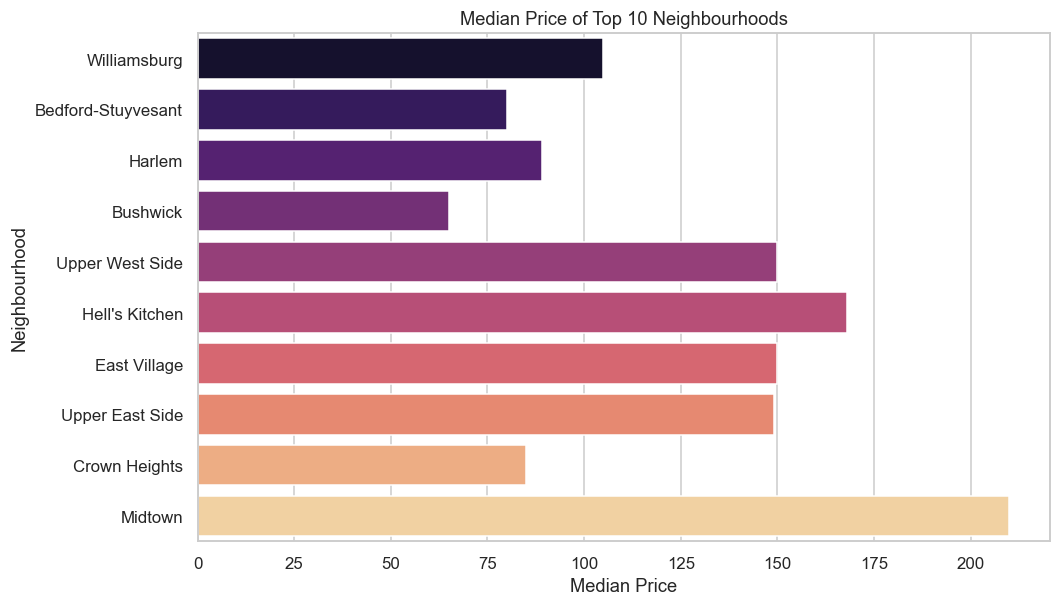

In [40]:
#For those top 10, plot their **median price**. Is listing density correlated with price?
top_10_neighbourhoods = top_neighbourhoods.index
median_price_top10 = df[df['neighbourhood'].isin(top_10_neighbourhoods)].groupby('neighbourhood')['price'].median().reindex(top_10_neighbourhoods)
plt.figure(figsize=(10,6)) 
sns.barplot(x=median_price_top10.values, y=median_price_top10.index, palette='magma')
plt.title("Median Price of Top 10 Neighbourhoods")
plt.xlabel("Median Price")
plt.ylabel("Neighbourhood") 


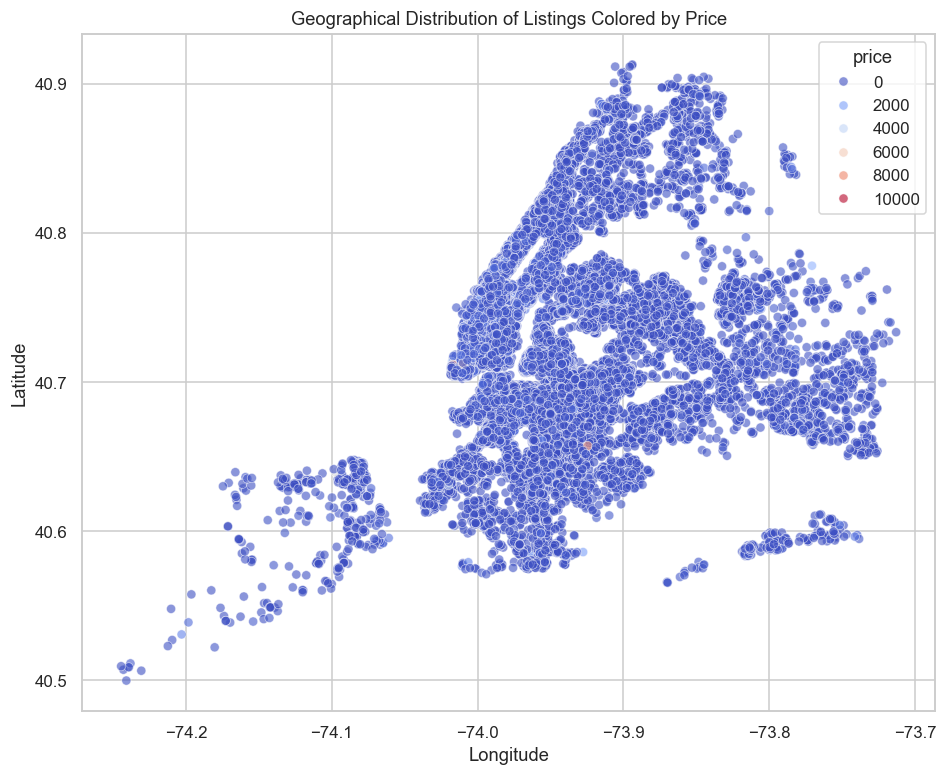

In [41]:
#Create a scatter plot of `latitude` vs `longitude`, coloured by `price`
plt.figure(figsize=(10,8))
sns.scatterplot(x='longitude', y='latitude', hue='price', data=df, palette='coolwarm', alpha=0.6)
plt.title("Geographical Distribution of Listings Colored by Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*


### Task 4.2 — The minimum_nights Anomaly (10 marks)

Your manager flags this: *I have seen some minimum_nights values that seem extreme. Can you investigate?*

- Plot the distribution of `minimum_nights`. What do you find?
I saw from the plot there is mostly  number of minimum_nights is lies.
- What % of listings require **30+ nights** minimum? **365 nights**?
Percentage of listings with minimum nights >= 30: 9.22% and Listings with minimum 365 nights: 0.09 %
  What does a 365-night minimum mean in practice — is this truly a short-term rental?
no its a lomg term pratice.
- Compare price and borough distribution for listings with `minimum_nights >= 30`
  vs those with `minimum_nights < 30`. Are they a different product category?
- Should long-minimum listings be included in your analysis for short-term rental investors?
  Make a clear recommendation.

> 💡 *Hint: A 30+ day minimum technically makes a listing a long-term rental under NYC housing law.
> That changes the regulatory picture entirely.*


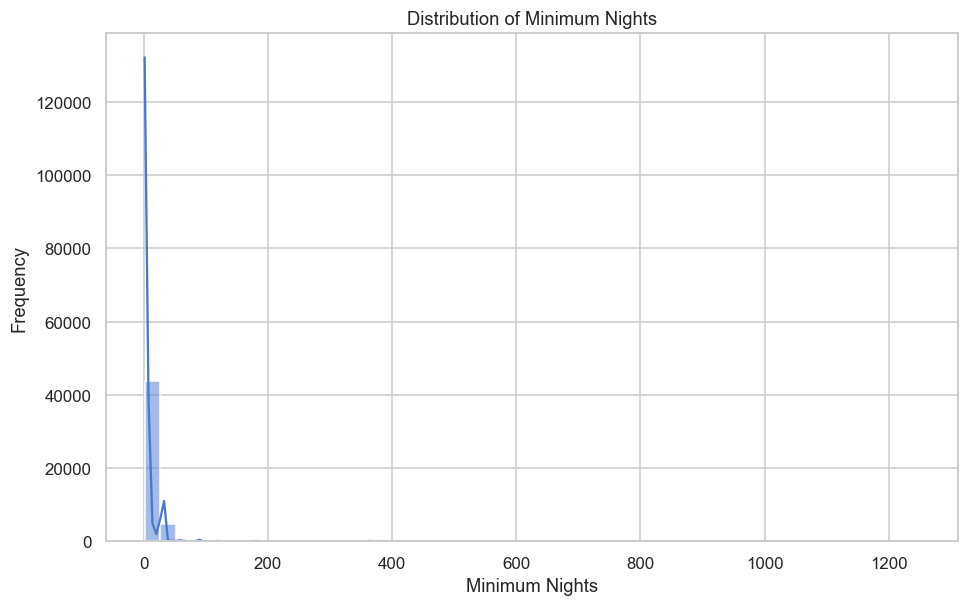

In [42]:
# Plot the distribution of `minimum_nights`. What do you find?
plt.figure(figsize=(10,6))
sns.histplot(df['minimum_nights'], bins=50, kde=True)
plt.title("Distribution of Minimum Nights")
plt.xlabel("Minimum Nights")
plt.ylabel("Frequency")
plt.show()

In [44]:
#% Listings with 30+ Nights
percentage_30_plus = (df['minimum_nights'] >= 30).sum() / len(df) * 100
print(f"Percentage of listings with minimum nights >= 30: {percentage_30_plus:.2f}%")
pct_365 = (df['minimum_nights'] >= 365).mean() * 100
print("Listings with minimum 365 nights:", round(pct_365,2), "%")

Percentage of listings with minimum nights >= 30: 9.22%
Listings with minimum 365 nights: 0.09 %


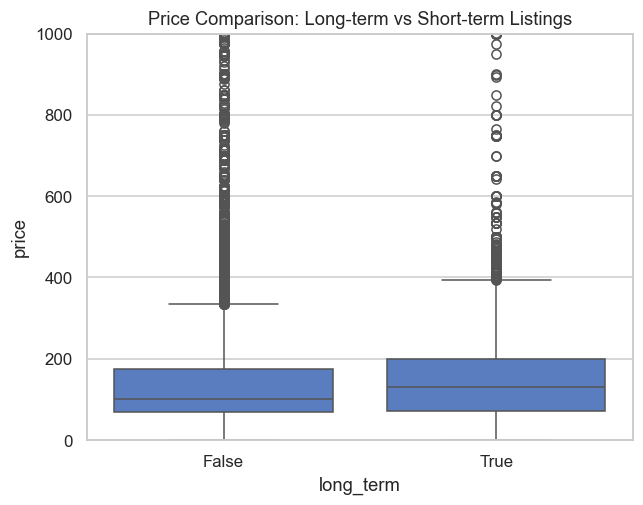

In [45]:
df['long_term'] = df['minimum_nights'] >= 30

sns.boxplot(x='long_term', y='price', data=df)
plt.ylim(0,1000)
plt.title("Price Comparison: Long-term vs Short-term Listings")
plt.show()

In [46]:
#Compare Borough Distribution
pd.crosstab(df['neighbourhood_group'], df['long_term'], normalize='index') * 100

long_term,False,True
neighbourhood_group,,
Bronx,96.516957,3.483043
Brooklyn,93.692797,6.307203
Manhattan,86.976594,13.023406
Queens,93.628662,6.371338
Staten Island,94.906166,5.093834


**✍️ Your Interpretation:**  
*(Write here)*


---

# 🔗 PART 5 — Correlation & Multivariate Analysis
### (10 Marks)

You have looked at variables individually. Now examine how they interact.


### Task 5.1 — Correlation Matrix (5 marks)

Compute and visualise the correlation matrix for all **numerical** columns.

- Which pairs of variables are most strongly correlated?
reviews_per_month and numbers_of_reviews
- Is `price` correlated with `number_of_reviews`? With `availability_365`?No
  Interpret the findings — do correlations imply causation here?
- Are there any correlations that surprise you?

> 💡 *Hint: A correlation near 0 does not always mean no relationship.
> Sometimes the relationship is non-linear. How might you check for that?*


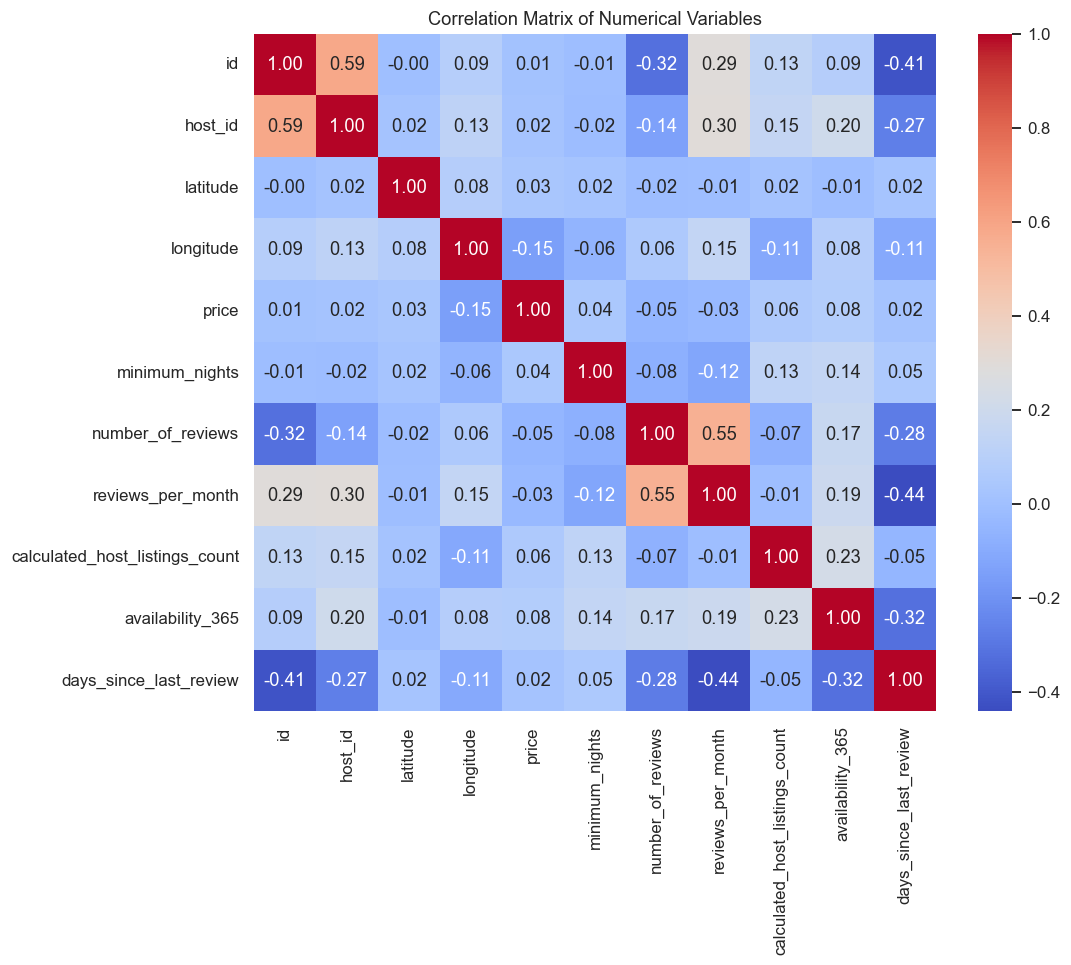

In [47]:
# Your code here
#Which pairs of variables are most strongly correlated?
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Numerical Variables")
plt.show()

**✍️ Your Interpretation:**  
*(Write here)*


### Task 5.2 — Pairplot Exploration (5 marks)

Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.

- Choose 3–4 variables wisely and justify your selection.
- What clusters or separations between room types do you observe?
I observe from this chart,The entire home/apt is high price range as compare to the private room and the shared room.
In the number_of_reviews and reviews_per_month the private rooms is high as compare to other.

> 💡 *Hint: Including all columns in a pairplot makes it unreadable. Be intentional.
> Which variables have already proven interesting in earlier tasks?*


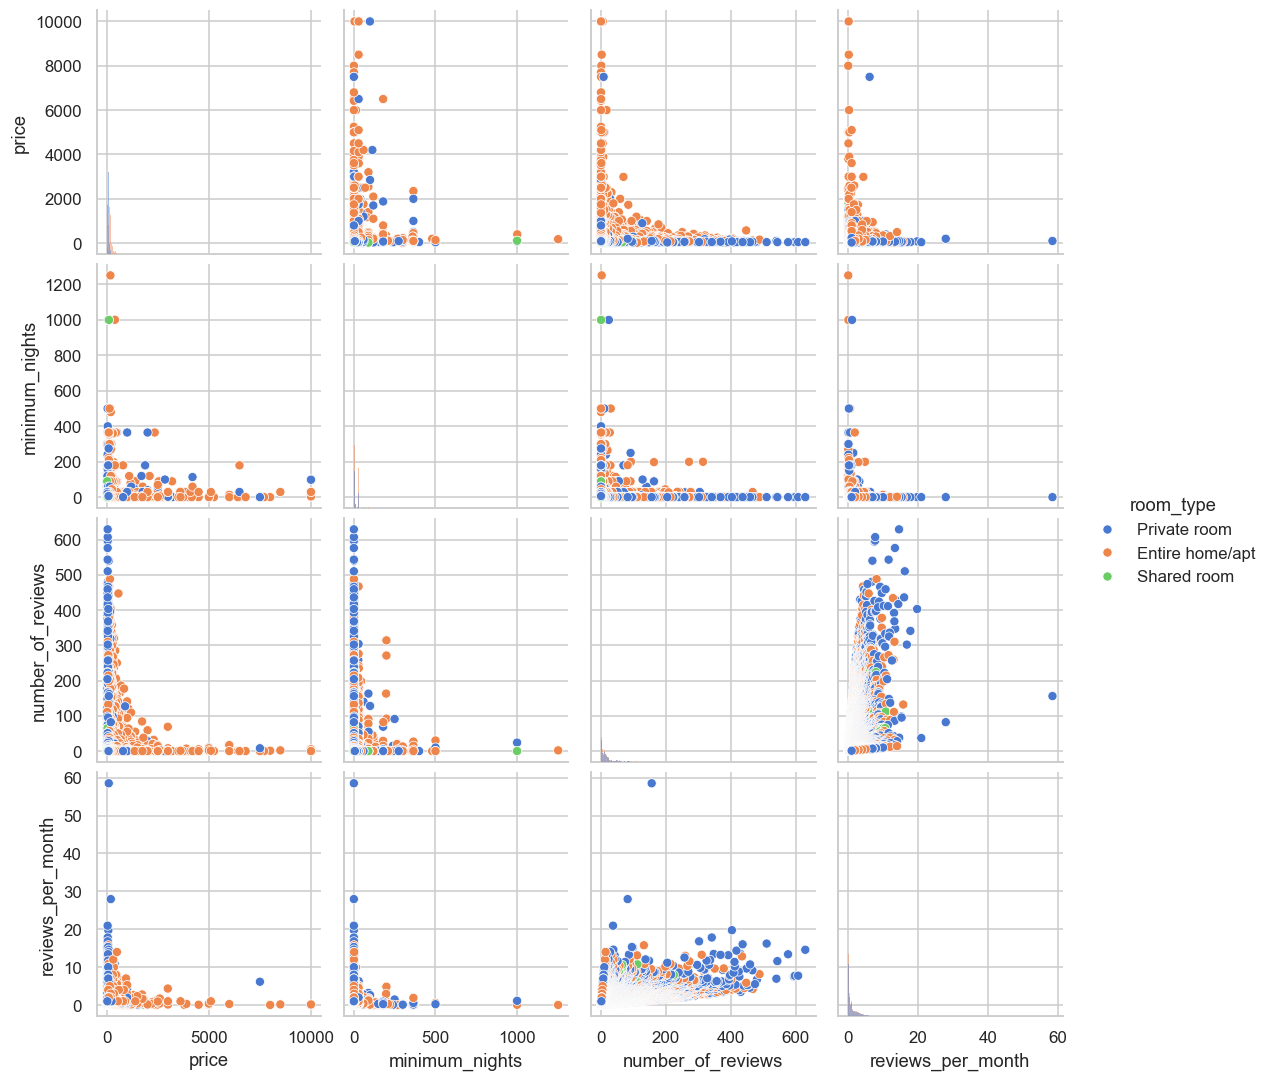

In [49]:
# Your code here
#Create a pairplot for a **subset** of meaningful numerical variables, coloured by `room_type`.
subset_cols = ['price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month']
sns.pairplot(df[subset_cols + ['room_type']], hue='room_type', diag_kind='hist')
plt.show()


**✍️ Your Interpretation:**  
*(Write here)*


---

# 📋 PART 6 — Final Investor Brief
### (10 Marks)

Synthesise your findings into a **short written brief** (Markdown only — no new code needed).

Your audience is **non-technical investors**. Write 250–350 words covering:

1. **Data Quality Warning:** What issues did you find that an investor must know before trusting any numbers?
2. **Manhattan Investor:** Opportunities and risks based purely on your EDA.
3. **Brooklyn Investor:** Same question for Brooklyn.
4. **Undecided Investor:** If you had to recommend one borough and one room type
   for consistent rental income, what would it be and why?
5. **One thing you would investigate next** if given more time.

> ⚠️ *You will be graded on the quality of reasoning, not just whether code runs.
> A technically correct analysis with a weak interpretation earns fewer marks than a thoughtful one.*


**✍️ Your Investor Brief:**

---

### Data Quality Warning
Before drawing conclusions, investors should be aware of several data quality issues. First, some listings have a price of **$0**, which is unrealistic and likely represents missing or incorrect data; these listings should be excluded from analysis. Second, the **reviews_per_month** column contains missing values, likely because many listings have never received a review. Third, the dataset includes listings with extremely high **minimum_nights** values (e.g., 365 nights), which effectively represent long-term rentals rather than short-term stays. Including these could distort results for short-term rental investors. Finally, the price distribution is highly **right-skewed**, with a small number of extremely expensive listings that may influence averages.


### Manhattan Investor
*(Write here)*
Manhattan listings generally command the **highest prices**, making it attractive for investors seeking premium revenue per booking. Entire homes and apartments in Manhattan show particularly high price levels compared with other boroughs. However, this market also comes with significant risks. Competition is intense, and higher prices may lead to **fewer bookings and reviews**, indicating potentially lower occupancy rates. Additionally, Manhattan properties may require higher upfront investment costs, meaning profitability depends heavily on maintaining strong booking demand.


### Brooklyn Investor
*(Write here)*
Brooklyn presents a different opportunity profile. Prices are generally **lower than Manhattan**, but the borough shows strong listing activity and often higher review counts, suggesting steady demand. Private rooms and moderately priced entire homes may attract budget-conscious travelers. The risk is that lower nightly prices may reduce revenue per booking. However, higher booking frequency could offset this, making Brooklyn attractive for investors focused on consistent occupancy rather than premium pricing.


### Recommendation for Undecided Investor
*(Write here)*
Based on the exploratory analysis, **Brooklyn private rooms** appear to offer the most consistent rental income potential. These listings tend to have moderate pricing, relatively strong review activity, and broader demand among travelers seeking affordable accommodation. This combination suggests a balance between occupancy and reasonable pricing, which is ideal for stable income.

### What I Would Investigate Next
*(Write here)*
If more time were available, the next step would be to analyze **occupancy patterns and seasonal demand** in more detail. Understanding how bookings fluctuate throughout the year would help investors estimate realistic annual revenue and identify peak earning periods.
---


---

# 🌟 BONUS CHALLENGE — For Those Who Finish Early
### (Up to 10 extra marks)

Choose **one** of the following:

---

### Bonus A — The Power Host Hypothesis

Define power hosts as those with more than 5 listings.

- Do power hosts charge significantly different prices compared to single-listing hosts?
- Do they receive more or fewer reviews per month?
- Is there a borough where power hosts are unusually concentrated?

Build a mini-analysis with at least 3 visualisations and a 100-word written conclusion.

---

### Bonus B — Listing Name Text Analysis

The `name` column contains free-text titles written by hosts.

- What are the most common words in listing names overall? In each borough?
- Do listings with words like luxury, cozy, or spacious in their name charge more on average?
- Can you identify naming patterns that correlate with higher prices?

> 💡 *Hint: The `str` accessor in pandas lets you work with string columns directly.
> For word frequency, think about splitting sentences and counting individual words.*


In [26]:
# Bonus code here (optional)


**✍️ Bonus Interpretation:**  
*(Write here)*


---

## 📊 Marking Rubric

| Part | Description | Marks |
|------|-------------|-------|
| Part 1 | First Contact (Inspection, Nulls, Duplicates) | 15 |
| Part 2 | Price Analysis | 25 |
| Part 3 | Host Behaviour & Market Structure | 20 |
| Part 4 | Geographic Deep Dive | 20 |
| Part 5 | Correlation & Multivariate | 10 |
| Part 6 | Investor Brief (Written) | 10 |
| **Total** | | **100** |
| Bonus | Power Host or Text Analysis | +10 |

**Code quality counts.** Plots must have titles, axis labels, and legends where appropriate.  
All cells must run top-to-bottom without errors.

---
*Dataset: New York City Airbnb Open Data 2019 — sourced from Inside Airbnb via public GitHub mirror.*  
*This notebook is for educational purposes only.*
